# Purpose:

This is a general notebook to demonstrate several linear models from SciKit Learn \
and how they be trained and used for future prediction.

## Background:


# Libraries

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#sklearn imports
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import add_dummy_feature, PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error


# Generate Data

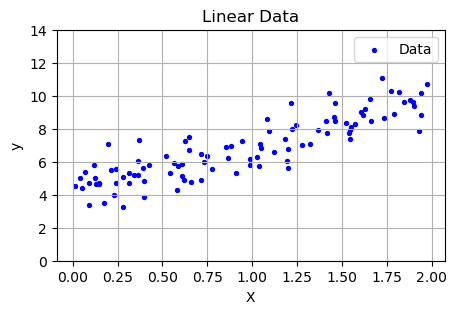

In [26]:
# to make this notebook's output stable across runs
np.random.seed(42)

# Generate some linear-looking data
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# Plot the data
plt.scatter(X, y, color='blue', label='Data', s=8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Data')
plt.legend()
plt.grid(True)
plt.ylim(0, 14)
plt.gcf().set_size_inches(5, 3)
plt.show()

# Linear Regression (Least Squares) Prediction

Find the best intercept and slope using the least squares method from the LinearRegression fit in SciKit Learn
- There is no cost function to minimize, so the least squares method directly computes  
    the slope and intercept and will likely be off.
- Additionally, linear regression is memory heavy as the data set gets bigger, 
    but predictions are extremely rapid.


In [24]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [27]:
# Use the model to make predictions
X_new = np.array([[0], [2]])

y_predict = lin_reg.predict(X_new)
y_predict

array([[4.21509616],
       [9.75532293]])

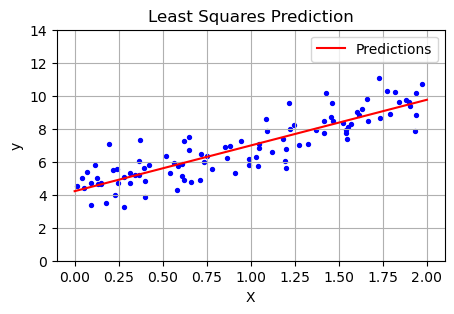

In [29]:
# Plot the data
plt.scatter(X, y, color='blue', s=8)
plt.plot(X_new, y_predict, 'red', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Least Squares Prediction')
plt.legend()
plt.grid(True)
plt.ylim(0, 14)
plt.gcf().set_size_inches(5, 3)
plt.show()

The intercept and slope are close to the original values used to generate the data ([4, 3]), but are slightly off. Using a method with cost function may help improve the results. 

# Gradient Descent

In [ ]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, 
                       n_iter_no_change=100, random_state=42)
                # This model runs for 1000 epochs, with a loss threshold (tolerance) of 1e-5, no regularization, a learning rate of 0.01, and a patience of 100 epochs.
sgd_reg.fit(X, y.ravel()) # ravel() flattens the array because fit expects a 1D array
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

The results from the Stocastic Gradient Descent algorithm produced the same intercept \
and slope, implying that both the least squares and Gradient descent are equally \
efficacious on this toy data set.

# Regularized models
Regularized models will prevent over-fitting of the model and reduces the influence \
of outliers on the intercept and slope estimation. Additionally, these methods are \
much better during feature selection in multiple linear regressions as they handle \
multiple collinearities and importance estimation. 

This is accomplished due to the addition of a cost function as a hyper-parameter. \
This cost function may slightly increase the training error but lower the general \
test error while improving the generalizability of the stability of the model.

### Make data with outliers for Regularized Regression

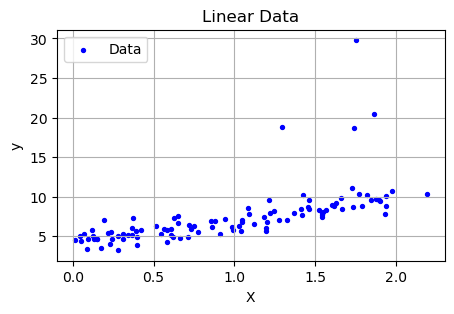

In [61]:
# to make this notebook's output stable across runs
np.random.seed(42)

# Generate some linear-looking data
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)


# Add outliers to the dataset
    # Approximately 5% of the data will be outliers
n_outliers = 5
X_outliers = np.random.uniform(1, 2.5, size=(n_outliers, 1))
y_outliers = 20 + 10 * np.random.randn(n_outliers, 1)  # Extreme outliers
X = np.vstack([X, X_outliers])
y = np.vstack([y, y_outliers])


# Plot the data
plt.scatter(X, y, color='blue', label='Data', s=8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Data')
plt.legend()
plt.grid(True)
#plt.ylim(0, 14)
plt.gcf().set_size_inches(5, 3)
plt.show()

## Ridge Regression
Ridge regression will prevent over-fitting using the L2 cost function that reduces \
the coefficients of dependent variables to prevent overfitting. Coefficients \
approach 0, but cannot be 0 (like in Lasso).

## Lasso Regression
Lasso regression is similar to ridge regression, but uses an L1 cost function to \
reduce bias in the regression. The primary functional difference between an L1 \
and L2 regression cost function is that the L1 cost function can reduce a function \
to zero while L2 can only minimize it.

## Elastic Net Regression
An elastic net regression is essentially a combination of Lasso and Ridge \
regression that uses both the L1 and L2 cost function. This allows for a severe \
reduction in the coefficient from L1 function, but can recover it with the L2 if \
the L1 is too aggressive. While this is important for individual regressions, it \
becomes even more important for multiple linear regressions during feature \
selection where there may be many individual features of small effect where Lasso \
may be too agressive, but Ridge is too permissive/inaccurate. 


*Note: The below implementation uses the default closed-form solution to calculate \
the cost function for each regression sub-type, but the cost function (theta) can \
also be calculated using gradient descent using the SGDRegressor() and specifying \
the correct cost function.

,Model,Intercept,Coefficients,RMSE
0,Original Metrics,4.000000,3.000000,NaN
1,Linear Regression,3.787670,3.715445,2.729746
2,Ridge Regression,3.879300,3.621926,2.730337
3,Lasso Regression,4.053308,3.444331,2.734707
4,Elastic Net Regression,4.339207,3.152539,2.751070


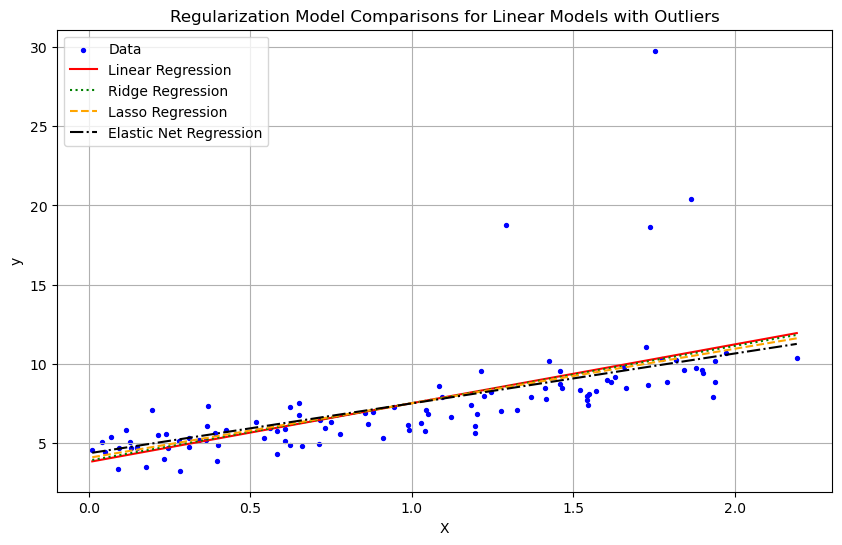

In [ ]:

# Fit a linear model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_rmse = np.sqrt(mean_squared_error(y, lin_reg.predict(X)))
#print(f'Linear Regression intercept and coefficients: {lin_reg.intercept_}, {lin_reg.coef_}')
#print(f'Linear Regression RMSE: {lin_rmse}')

# Fit a Ridge model
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_rmse = np.sqrt(mean_squared_error(y, ridge_reg.predict(X)))
#print(f'Ridge Regression intercept and coefficients: {ridge_reg.intercept_}, {ridge_reg.coef_}')
#print(f'Ridge Regression RMSE: {ridge_rmse}')

# Fit a Lasso model
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_rmse = np.sqrt(mean_squared_error(y, lasso_reg.predict(X)))
#print(f'Lasso Regression intercept and coefficients: {lasso_reg.intercept_}, {lasso_reg.coef_}')
#print(f'Lasso Regression RMSE: {lasso_rmse}')

# Fit an Elastic Net model
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net_rmse = np.sqrt(mean_squared_error(y, elastic_net.predict(X)))
#print(f'Elastic Net Regression intercept and coefficients: {elastic_net.intercept_}, {elastic_net.coef_}')
#print(f'Elastic Net Regression RMSE: {elastic_net_rmse}')

# Create a DataFrame to store the results
results = pd.DataFrame({
    "Model": ["Original Metrics", "Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"],
    "Intercept": [4, lin_reg.intercept_[0], ridge_reg.intercept_[0], lasso_reg.intercept_[0], elastic_net.intercept_[0]],
    "Coefficients": [3, lin_reg.coef_[0][0], ridge_reg.coef_[0][0], lasso_reg.coef_[0], elastic_net.coef_[0]],
    "RMSE": [None, lin_rmse, ridge_rmse, lasso_rmse, elastic_net_rmse]
})

# Display the DataFrame
display(results)

# Plot the data and model fits
plt.scatter(X, y, color='blue', label='Data', s=8)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    # New X values for plotting the predictions
plt.plot(X_range, lin_reg.predict(X_range), 'r-', label='Linear Regression')
plt.plot(X_range, ridge_reg.predict(X_range), 'g:', label='Ridge Regression')
plt.plot(X_range, lasso_reg.predict(X_range), color='orange', linestyle='--', label='Lasso Regression')
plt.plot(X_range, elastic_net.predict(X_range), color='black', linestyle='-.', label='Elastic Net Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regularization Model Comparisons for Linear Models with Outliers')
plt.legend()
plt.grid(True)
plt.gcf().set_size_inches(10, 6)
plt.show()


For this dataset, each linear model does reasonablyewll at predicting the intercept \
and coefficents used to generate the data in the absence of outliers. However, the \
lasso regression did a better job at identifying the correct intercept while the \
elastic net did a better job at predicting the coeffecient (slope), which is \
argueable more important. 

The linear and ridge regression methods were worse \
models despite have a lower RMSE and will have increased error at the high and \
low end of the X distribution due to the outliers skewing the slope and intercept \
of the model. This error will drastically increase for values of X that are beyond \
the range of X that was used to train the model, which should be assessed with \
causion regardless of the model used.


# Polynomial Regression

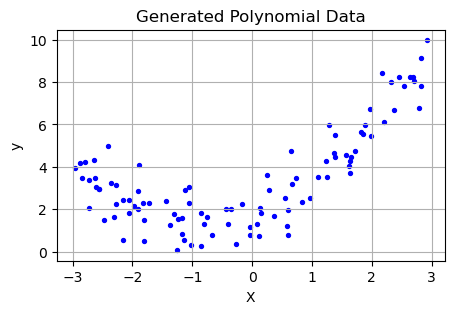

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate some polynomial-looking data
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)


# Plot the data
plt.scatter(X, y, color='blue', s=8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Polynomial Data')
plt.grid(True)
plt.gcf().set_size_inches(5, 3)
plt.show()

## Polynomial Regression

In [4]:

# Transform the data to include a second degree polynomial feature
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Fit the transformed features to a linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

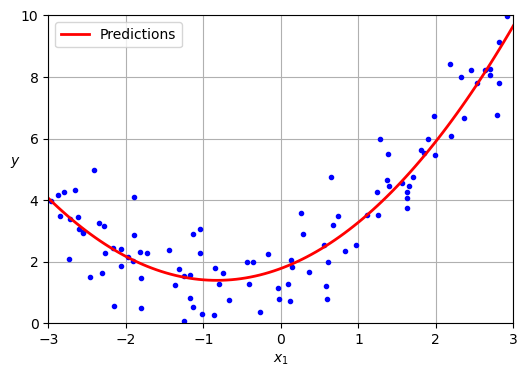

In [5]:
# Graph the polynomial fit.
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

This is a close fit to the original equation used to generate the data, where the intercept was 2.0 (1.78 predicted), and the first and second degree coefficients were 0.5 and 1.0 (0.56 and 0.933 predicted), respectively.

# Learning Curves

Using learning curves to assess the fit of different degrees of polynomials. 

- This shows how to assess the fit of higher polynomial fits.



*Note: Optimal polynomial fit can also be determined using Lasso regression using the following pipeline:
- PolynomialFeatures()
- StandardScaler()
- Lasso()

### Underfit
Linear model fit on polynomial data

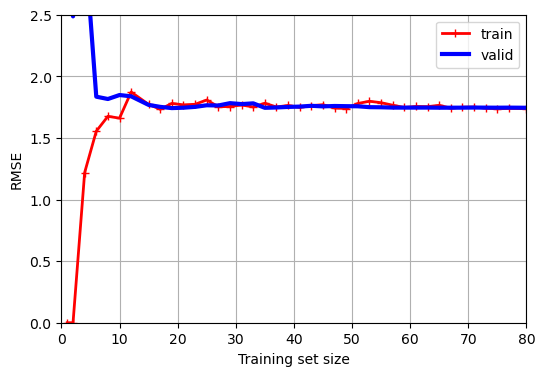

In [9]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=1, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
plt.show()

For underfit data, the error (RMSE) training data rapidly converges with validation data at a relatively high error rate and plateaus.

### Good Fit

Second-degree polynomial on second degree polynomial on second-degree data.

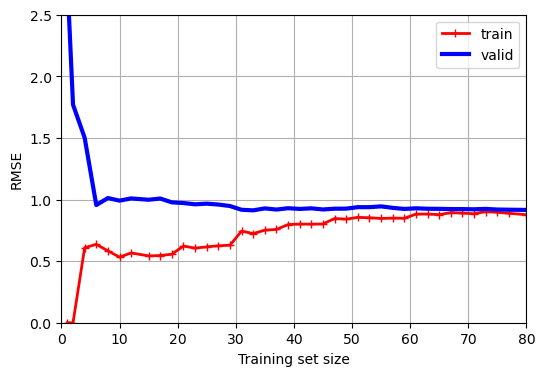

In [8]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
plt.show()

For a well-fit model, the error of the training data slowly approaches the error of the validation data and eventually converges at a lower relative error (RMSE) compared with underfit data.

### Overfit model
A tenth-degree polynomial on second degree data.

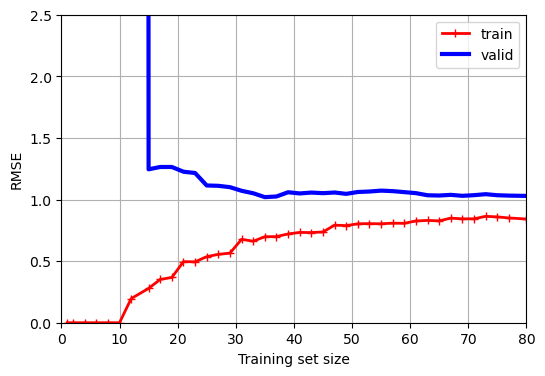

In [ ]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error")

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.legend(loc="upper right")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.axis([0, 80, 0, 2.5])
plt.show()

For over-fit data, the error (RMSE) of the training set slowly increase as the training data set increases in size, but will never converge or reach the minimum error of the validation set.

### Graphing the under, good, and over-fit models on the polynomial data.

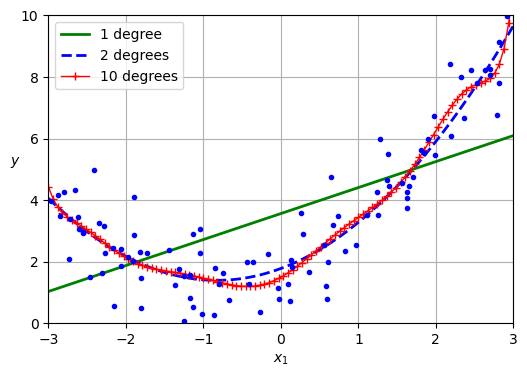

In [16]:
plt.figure(figsize=(6, 4))

for style, width, degree in (("g-", 2, 1), ("b--", 2, 2), ("r-+", 1, 10)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = make_pipeline(polybig_features, std_scaler, lin_reg)
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    label = f"{degree} degree{'s' if degree > 1 else ''}"
    plt.plot(X_new, y_newbig, style, label=label, linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

# Logistic regression

Logisitic regression is a simple why to establish a classifier for individual or \
multiple groups using a probabilistic framework.

For this example, I will use the classic Iris dataset pre-loaded into SKLearn.


## Binary Logisitic Regression
For the first example, I will generate a model to predict whether a sample is the \
plant species *Iris virginica* using one feature (petal width) or multiple features \
(petal width and length). 

In [74]:
# Load dataset
iris = load_iris(as_frame=True)

iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [75]:
# Define the dataset and split into training and testing sets
X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == "virginica"

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [76]:
# Train the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

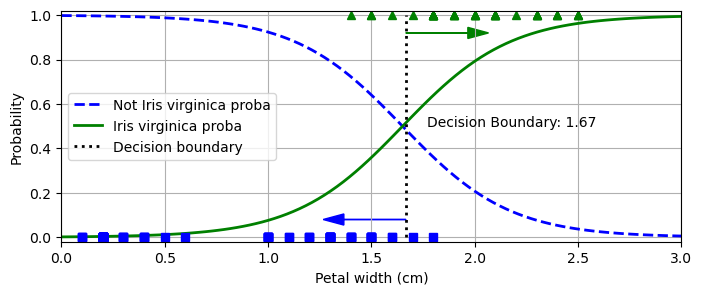

In [82]:
# Plot the outcome

X_new = np.linspace(0, 3, 100).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
plt.text(decision_boundary + 0.1, 0.5, f"Decision Boundary: {decision_boundary:.2f}", fontsize=10, color="black")
plt.show()

The general descision boundry is a hard boundry where the model will strictly \
define all samples with a petal width larger than 1.67 as *Iris virginica* while \
all petal widths below 1.67 as not *I. virginica*. In these cases it is preferrable \
to include predict_prob() in the model to estimate the confidence in the model's \
prediction.

Additionally, it may be worth including more features to see if we can improve \
the prediction.

### Logistic Multiple Regression 

In [83]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(C=2, random_state=42)

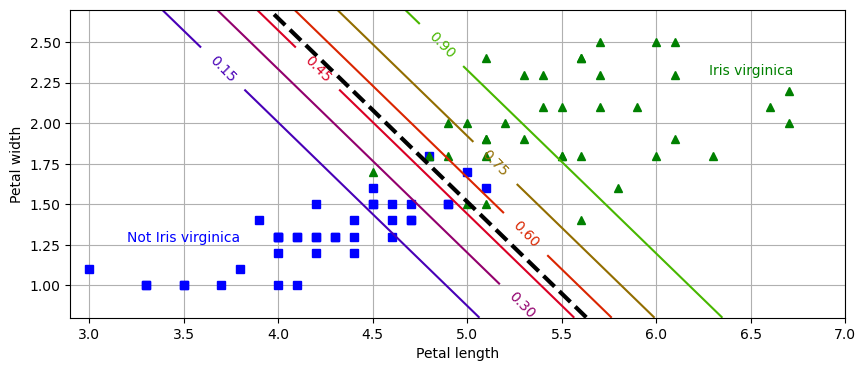

In [85]:
# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1),
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])
             / log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
plt.show()

Using mulitple predictors (petal width and length) improves the ability of the \
logistic regression to separate out *I. virginica* from the other Iris species. \
The current graph not only demonstrates the decision boundry, but also multiple \
probablistic cutoffs for the model's confidence that a sample is *I. virginica* \
during prediction.

## Multinomial Logistic Regression

Logistic regression can also be used to identify multiple categories. This is an \
example where Mulitnomial Logisitic Regression can be used predict all three \
species of Iris in the example dataset.

In [90]:
# Get data from for all three Iris species
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train the multinomial model
multilog_reg = LogisticRegression(C=30, random_state=42)
multilog_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

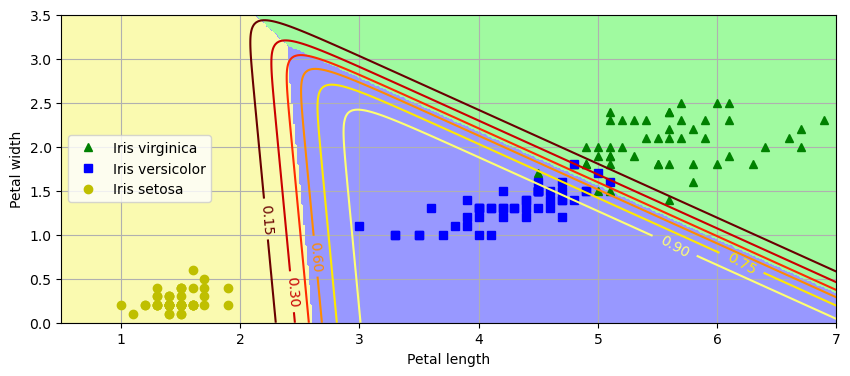

In [92]:
custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = multilog_reg.predict_proba(X_new)
y_predict = multilog_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()
plt.show()

This graph shows the results from a multinomial logistic regression and their \
decision boundaries for for all three Iris sepecies based on their petal width and \
length. You can easily see the separation between *I. setosa* and the other species, \
but both *I. versicolor* and *I. virginica* are more difficult to separate at the \
margins. This illustrates the importance of including the probability into the \
logistic regression during regression/classification.